# ModelTrainer — Manual Validation Notebook

Trains the final decoders at a chosen timepoint and visualises the spatial patterns.

**Can be run standalone** (set `TIMEPOINT` explicitly) or **chained from the evaluator**
(set `TIMEPOINT = None` to run ModelEvaluator first and use `suggested_timepoint`).

The trainer returns trained models and spatial patterns only. Bundling with Phase 1
artifacts and saving to disk is handled by a separate orchestration layer.

**This notebook is for validation only — not part of the app.**

Expected runtime with `QUICK_MODE = True`: **< 1 minute** (no CV, just a single fit per task).

In [1]:
import sys
from pathlib import Path

# ── Locate repo root ──────────────────────────────────────────────────────────
_repo = next(
    (p.resolve() for p in [Path("."), Path(".."), Path("../.."), Path("../../..")]
     if (p / "data" / "preprocessed").is_dir()),
    None,
)
assert _repo is not None, (
    "Could not find repo root (expected a parent directory containing data/preprocessed/). "
    "Launch Jupyter from within the reactivation-decoder project tree."
)

# ── Locate online_decoder/src ─────────────────────────────────────────────────
_src = next(
    (p.resolve() for p in [Path("src"), Path("../src"), Path("../../src")]
     if (p / "backend").is_dir()),
    None,
)
assert _src is not None, (
    "Could not find src/backend/. "
    "Launch Jupyter from within the online_decoder/ directory tree."
)
sys.path.insert(0, str(_src))
# ─────────────────────────────────────────────────────────────────────────────

# ── Data source ───────────────────────────────────────────────────────────────
# "preprocessed"  — load an existing .fif directly (fast)
# "full_pipeline" — run OfflinePreprocessor from raw .vhdr (slow)
DATA_SOURCE = "preprocessed"

EPOCHS_PATH = _repo / "data/preprocessed/sub_001/sub_001_prepro-epo.fif"
RAW_DIR     = _repo / "data/raw/sub_001/"
CONFIG_PATH = _src.parent.parent / "experiment_config.yaml"
# ─────────────────────────────────────────────────────────────────────────────

# Quick mode: crop to 0–0.8 s for faster iteration.
QUICK_MODE = True

# Set TIMEPOINT to a float (e.g. 0.35) to skip the evaluator step.
# Set to None to run ModelEvaluator first and use its suggested_timepoint.
TIMEPOINT = None

import mne
import numpy as np
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import time

from backend.core.settings_manager import SettingsManager
from backend.offline_phase.preprocessor import OfflinePreprocessor
from backend.offline_phase.evaluator import ModelEvaluator
from backend.offline_phase.trainer import ModelTrainer

mne.set_log_level("WARNING")
print("Imports OK")
print(f"Repo root  : {_repo}")
print(f"src        : {_src}")
print(f"Data source: {DATA_SOURCE}")
print(f"Quick mode : {QUICK_MODE}")
print(f"Timepoint  : {TIMEPOINT} ({'manual' if TIMEPOINT is not None else 'from evaluator'})")

Imports OK
Repo root  : /home/roiguri/projects/uni/reactivation-decoder
src        : /home/roiguri/projects/uni/reactivation-decoder/online_decoder/src
Data source: preprocessed
Quick mode : True
Timepoint  : None (from evaluator)


---
## Load Epochs

Two paths depending on `DATA_SOURCE`:

- **`"preprocessed"`** — reads an existing `.fif` file produced by a previous run.
- **`"full_pipeline"`** — runs `OfflinePreprocessor` from the raw `.vhdr`, pauses for ICA
  review, then finishes the pipeline and loads the resulting epochs.

In [2]:
if DATA_SOURCE == "preprocessed":
    assert EPOCHS_PATH.exists(), (
        f"File not found: {EPOCHS_PATH.resolve()}\n"
        "Adjust EPOCHS_PATH in the config cell, or set DATA_SOURCE = 'full_pipeline'."
    )
    epochs = mne.read_epochs(EPOCHS_PATH, preload=True, verbose=False)
    preprocessor = None

elif DATA_SOURCE == "full_pipeline":
    assert RAW_DIR.exists(),     f"RAW_DIR not found: {RAW_DIR.resolve()}"
    assert CONFIG_PATH.exists(), f"CONFIG_PATH not found: {CONFIG_PATH.resolve()}"

    settings        = SettingsManager(CONFIG_PATH)
    prepro_params   = settings.get_preprocessing_params()
    event_mapping   = settings.get_event_mapping()

    preprocessor = OfflinePreprocessor(
        data_dir=RAW_DIR,
        preprocessing_settings=prepro_params,
    )
    print(f"Subject    : {preprocessor.subject_id}")
    assert preprocessor.vhdr is not None, "No .vhdr found — check RAW_DIR"

    print("\nRunning Step 1 (filter → resample → bad channels → ICA)…")
    suggested = preprocessor.run_step1_prepare_ica()
    print(f"\nSuggested artifact components: {suggested}")
    print("→ Review the components, then set EXCLUDE_COMPONENTS in the next cell and run it.")

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}. Use 'preprocessed' or 'full_pipeline'.")

In [ ]:
# ── Full pipeline only: ICA review + Step 2 ───────────────────────────────────
if preprocessor is not None:
    EXCLUDE_COMPONENTS = list(suggested)
    # EXCLUDE_COMPONENTS += [0, 3]  # add indices after visual inspection

    preprocessor.run_step2_finish_pipeline(
        exclude_components=EXCLUDE_COMPONENTS,
        event_mapping=event_mapping,
        output_dir=_repo / "data_vault/sub_001/",
    )
    epochs = preprocessor.epochs
    print(f"\n✓ Pipeline complete — {len(epochs)} epochs")
else:
    print("Skipped (DATA_SOURCE = 'preprocessed')")

In [3]:
if QUICK_MODE:
    epochs = epochs.crop(tmin=0.0, tmax=0.8)

print(f"n_epochs   : {len(epochs)}")
print(f"n_channels : {len(epochs.ch_names)}")
print(f"n_times    : {len(epochs.times)}")
print(f"time range : {epochs.tmin:.2f} s  →  {epochs.tmax:.2f} s")
print(f"sfreq      : {epochs.info['sfreq']:.0f} Hz")
print("\nEvent counts:")
for name, code in sorted(epochs.event_id.items(), key=lambda x: x[1]):
    count = int((epochs.events[:, 2] == code).sum())
    print(f"  {name:14s} (id={code:3d}): {count} epochs")

assert len(epochs) > 0, "No epochs loaded"
assert epochs.preload,   "Epochs must be preloaded"
print("\n✓ Epochs ready")

n_epochs   : 560
n_channels : 64
n_times    : 81
time range : 0.00 s  →  0.80 s
sfreq      : 100 Hz

Event counts:
  object         (id= 31): 94 epochs
  feature        (id= 32): 96 epochs
  scene          (id= 33): 93 epochs
  retrieval      (id= 41): 86 epochs
  binding        (id= 51): 96 epochs
  baseline       (id= 61): 95 epochs

✓ Epochs ready


---
## Define Decoder Tasks

In [4]:
CV_FOLDS = 3 if QUICK_MODE else 5

decoder_settings = {
    "model": "LDA",
    "params": {"solver": "lsqr", "shrinkage": "auto"},
    "scale_method": "standard",
    "cv": {"k": CV_FOLDS},
    "random_state": 42,
    "tasks": [
        {
            "name": "object vs scene+feature",
            "pos_labels": ["object"],
            "neg_labels": ["scene", "feature"],
        },
        {
            "name": "scene vs object+feature",
            "pos_labels": ["scene"],
            "neg_labels": ["object", "feature"],
        },
        {
            "name": "feature vs object+scene",
            "pos_labels": ["feature"],
            "neg_labels": ["object", "scene"],
        },
    ],
}

known_labels = set(epochs.event_id.keys())
for t in decoder_settings["tasks"]:
    for lbl in t["pos_labels"] + t["neg_labels"]:
        assert lbl in known_labels, f"Label '{lbl}' not in epochs.event_id: {known_labels}"

print("Tasks:")
for t in decoder_settings["tasks"]:
    print(f"  {t['name']}")
print("\n✓ All task labels found in epochs")

Tasks:
  object vs scene+feature
  scene vs object+feature
  feature vs object+scene

✓ All task labels found in epochs


---
## Optionally Run Evaluator to Get Suggested Timepoint

Skipped when `TIMEPOINT` is already set.

In [5]:
if TIMEPOINT is None:
    print("TIMEPOINT not set — running ModelEvaluator to get suggested_timepoint…")
    t0 = time.time()
    eval_result = ModelEvaluator(epochs, decoder_settings).run_evaluation()
    TIMEPOINT = eval_result["suggested_timepoint"]
    print(f"Done in {time.time() - t0:.0f} s")
    print(f"Suggested timepoint : {TIMEPOINT:.3f} s  (avg peak AUC = {eval_result['average_peak_auc']:.4f})")
else:
    print(f"Using manual TIMEPOINT = {TIMEPOINT:.3f} s")

assert epochs.tmin <= TIMEPOINT <= epochs.tmax, (
    f"TIMEPOINT {TIMEPOINT:.3f} s is outside the epoch window [{epochs.tmin:.3f}, {epochs.tmax:.3f}] s."
)
print(f"\n✓ Timepoint {TIMEPOINT:.3f} s is within epoch window")

TIMEPOINT not set — running ModelEvaluator to get suggested_timepoint…
Done in 174 s
Suggested timepoint : 0.220 s  (avg peak AUC = 0.8734)

✓ Timepoint 0.220 s is within epoch window


---
## Run ModelTrainer

In [6]:
print(f"Training at timepoint : {TIMEPOINT:.3f} s")
print()

t0 = time.time()
trainer = ModelTrainer(epochs, decoder_settings)
result = trainer.run_training(TIMEPOINT)
elapsed = time.time() - t0

print(f"Done in {elapsed:.1f} s")

# ── Structural assertions ─────────────────────────────────────────────────────
assert set(result.keys()) == {"models", "spatial_patterns", "mne_info"}
assert len(result["models"]) == len(decoder_settings["tasks"])
assert len(result["spatial_patterns"]) == len(decoder_settings["tasks"])
for name, pattern in result["spatial_patterns"].items():
    assert pattern.shape == (len(epochs.ch_names),), f"{name}: pattern shape wrong"

print(f"\n✓ Models trained       : {list(result['models'].keys())}")
print(f"✓ Spatial patterns     : {list(result['spatial_patterns'].keys())}")

Training at timepoint : 0.220 s

Done in 2.0 s

✓ Models trained       : ['object vs scene+feature', 'scene vs object+feature', 'feature vs object+scene']
✓ Spatial patterns     : ['object vs scene+feature', 'scene vs object+feature', 'feature vs object+scene']


---
## Visualise Spatial Patterns

Haufe et al. 2014 activation patterns — one topomap per decoder task.

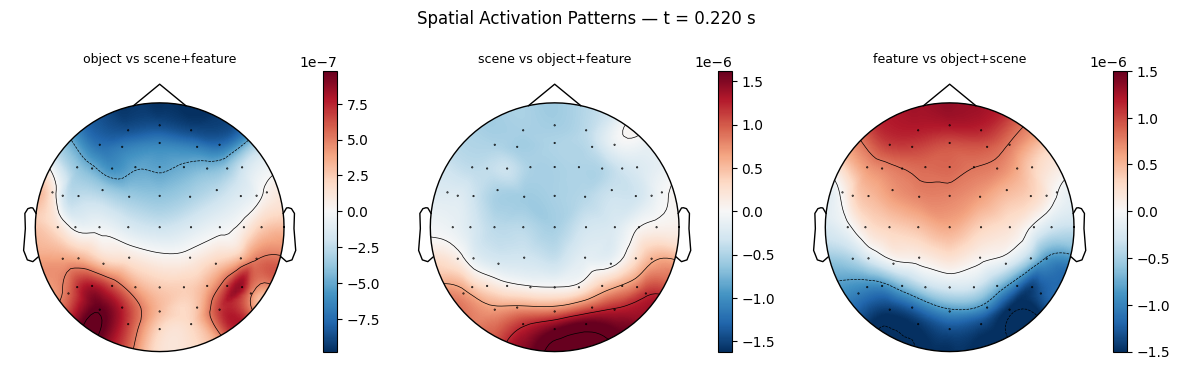

In [7]:
n_tasks = len(result["spatial_patterns"])
fig, axes = plt.subplots(1, n_tasks, figsize=(4 * n_tasks, 3.5))

if n_tasks == 1:
    axes = [axes]

info = result["mne_info"]

for ax, (task_name, pattern) in zip(axes, result["spatial_patterns"].items()):
    im, _ = mne.viz.plot_topomap(
        pattern,
        info,
        axes=ax,
        show=False,
        contours=4,
    )
    ax.set_title(task_name, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"Spatial Activation Patterns — t = {TIMEPOINT:.3f} s",
    y=1.02,
)
plt.tight_layout()
plt.show()

---
## Summary

If all cells passed:

- **Spatial patterns** (topomaps) show the biological source distribution for each decoder.
  A clean, focussed pattern suggests the classifier learned a neurophysiologically plausible
  spatial filter. Diffuse or noisy patterns may indicate poor signal quality or a suboptimal timepoint.
- **`result['models']`** contains the fitted sklearn pipelines, ready to be bundled by the
  orchestration layer with the Phase 1 `online_state` and saved to `decoder_pipeline.joblib`.

**Next step:** implement the orchestration layer that collects
`OfflinePreprocessor.export_online_state()` and `ModelTrainer.run_training()` outputs,
bundles them, and persists to disk.